# Hybrid glider vs. N-Sensor Defender: Strong Stackelberg Security Game (SSG)

This notebook extends the single-sensor SSG (`hybrid_glider_SSG.ipynb`) to a
**multi-sensor defender** that places exactly `N_SENSORS >= 1` co-located
radar + acoustic units anywhere on the perimeter candidate set `D_SITES`.

**Leader (defender).** Places `N_SENSORS` sensors chosen from `D_SITES`
(no repeated sites). Objective $J_D = \beta_1 P_D + \beta_2\,\mathrm{Coverage}$
(maximize), where Coverage is the **union** of the `N_SENSORS` coverage discs.

**Follower (attacker).** A boost-glide vehicle that best-responds to the full
sensor array. Detection intensities from all sensors are summed under
independent-Poisson fusion: $H = \int\sum_k\sum_j \lambda_{kj}\,\mathrm{d}t$,
$P_D = 1-e^{-H}$ (more sensors always hurts the attacker).

**Solution concept.** Strong Stackelberg Equilibrium (SSE) via deterministic
enumeration over $\binom{|D|}{N}$ sensor placements.

## Changes from the single-sensor notebook

| Component | Change |
|-----------|--------|
| `N_SENSORS` | new constant (set to 1 to reproduce original) |
| `hazard_glide`, `hazard_powered` | sum over `sensors` list |
| `glide_dp` | `sensor` → `sensors` list, sum radar rates |
| `coverage` | union of N coverage intervals |
| `attacker_BR` | `sensor` → `sensors` list |
| SSE sweep | `itertools.combinations(D_SITES, N_SENSORS)` |
| Baselines | naive = evenly-spaced; greedy = submodular coverage |
| Figure | Panel A bar chart for N>1; Panel B shows all sensor sites |

In [1]:
import math, time, heapq, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Constants, vehicle, mission, defender, threat, objectives

In [2]:
# --- physics / vehicle ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(45.0)
Z_GOAL, H_GOAL = 2500.0, 0.0
DT_GLIDE, DT_POW = 1.0, 0.25
V_MAX_GLIDE = 60.0

# --- DEFENDER (leader): N_SENSORS co-located radar+acoustic units on perimeter ---
N_SENSORS   = 2                                                    # >= 1; set to 1 for original
R_PERIM     = 2000.0
D_SITES     = np.arange(Z_GOAL - R_PERIM, Z_GOAL + 1, 250.0)     # candidate z positions (h=0)
CORRIDOR_Z0 = 500.0
R_DET       = 600.0

# --- threat model ---
# Calibrated to a low, separable P_D band (see 'Calibration & literature basis').
# Forms: radar r^-4 (radar range eq., Skolnik); aspect-dep. signature + range (Inanc et al., JGCD 2008);
# acoustic v^n / r^2 (rotor aeroacoustics + spherical spreading). Scale = reference-range anchor.
LAM_DOPPLER  = 4.5e2    # = 1.5e4 x 0.03
LAM_RCS      = 6.0e3    # = 2.0e5 x 0.03
SIGMA0, SIGMA_MIN = 1.0, 0.1
LAM_ACOUSTIC = 2.4e-3   # = 0.08 x 0.03
N_ACOUSTIC   = 4
R_FLOOR      = 10.0

# --- objectives ---
A1_PD, A2_T   = 1.0, 0.002
B1_PD, B2_COV = 1.0, 0.5

# --- glide cost shaping ---
W_TIME_GLIDE = 0.005
W_SMOOTH     = 2.0
W_SPEED      = 1.5
H_CLEAR      = 15.0
Z_FLARE      = 300.0
H_HEADROOM_G = 100.0

# --- powered cost ---
W_TIME_POW, W_FUEL_POW = 1.0, 0.1

# --- best-response / SSE controls ---
V_SW_FLOOR = 16.0
N_SWITCH   = 6
TIE_EPS    = 0.01

# --- state-grid resolutions ---
RANK_GRID  = dict(dz=100.0, dh=10.0, dv=4.0, dgam=math.radians(4.0))  # selection only
FINAL_GRID = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))

print(f'N_SENSORS={N_SENSORS}, |D_SITES|={len(D_SITES)}, '
      f'placements to evaluate: C({len(D_SITES)},{N_SENSORS})='
      f'{len(list(itertools.combinations(D_SITES, N_SENSORS)))}')

N_SENSORS=2, |D_SITES|=9, placements to evaluate: C(9,2)=36


## Dynamics

In [3]:
def eom(v, gamma, CL, T):
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Threat model — multi-sensor Poisson fusion

Per-sensor intensities are unchanged. For a sensor array, intensities **add**
across sensors (independent Poisson channels), so:

$$H = \int_0^T \sum_{j=1}^{N} \bigl[\lambda_\mathrm{dop}^{(j)} + \lambda_\mathrm{rcs}^{(j)} + \lambda_\mathrm{ac}^{(j)}\bigr]\,\mathrm{d}t, \quad P_D = 1 - e^{-H}$$

`hazard_glide` and `hazard_powered` now accept a **list of sensor positions**.

In [4]:
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    dz, dh = z - sensor[0], h - sensor[1]
    vr = (v*math.cos(gamma)*dz + v*math.sin(gamma)*dh) / r
    return LAM_DOPPLER * vr*vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    ez, eh = (sensor[0]-z)/r, (sensor[1]-h)/r
    c = ez*(-math.sin(gamma)) + eh*math.cos(gamma)
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c*c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    r = _range(z, h, sensor)
    return LAM_ACOUSTIC * v**N_ACOUSTIC / (r*r)

def hazard_glide(pts, sensors, dt_sub):
    '''Radar hazard over a glide trajectory, summed over all sensors.'''
    return sum(
        sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        for (z, h, v, g, _T) in pts[:-1]
    )

def hazard_powered(pts, sensors, dt_sub):
    '''Radar + acoustic hazard over a powered trajectory, summed over all sensors.'''
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        if T > 0:
            cost += sum(acoustic_rate(z, h, v, s) for s in sensors) * dt_sub
    return cost

def pod_from_hazard(hz):
    return 1.0 - math.exp(-hz)

## Calibration and literature basis

The detection forms are standard; the scale is ours.

- **Exponential (Koopman) detection law.** $P_D = 1-\exp(-\int \eta\,dt)$ with instantaneous rate $\eta$ is Koopman search theory (Koopman, *Search and Screening*, 1980; Stone, *Theory of Optimal Search*, 1975). Independent multi-sensor fusion $1-P_{nd}=1-\prod_k(1-p_{d,k})$ reduces to summing intensities, which is what `hazard_*` do.
- **Radar $r^{-4}$.** Received power, hence SNR and detection rate, scale as $\sigma/R^4$ from the radar range equation (Skolnik, *Introduction to Radar Systems*).
- **Aspect-dependent signature + range.** $p_d=f(\text{signature}(\text{aspect}),\,R)$ and $P_{nd}=\prod_k(1-p_{d,k})$ follow Inanc, Muezzinoglu, Misovec, Murray, *Framework for Low-Observable Trajectory Generation in Presence of Multiple Radars*, J. Guidance, Control, and Dynamics 31(5), 2008 (CDC 2004 precursor); see also Pachter and Hebert, ACC 2001, for the radar-exposure integral.
- **Acoustic $v^n/r^2$.** Propeller/rotor broadband source level grows with tip speed ($n\approx4$–$6$) and intensity falls with $1/r^2$ spherical spreading (UAV-acoustic detection review, *AIP Advances* 2025; flyover measurements, *Applied Acoustics*).

**On $\lambda$.** No source gives a transferable numeric $\lambda$: in Inanc it is tabular data from a platform model, and in the radar equation $\lambda$ is a lumped system constant (transmit power, aperture, noise floor, detection threshold). The defensible practice is to fix $\lambda$ by a *reference detection range*, choosing it so that a best-responding attacker's $P_D$ stays in a band where the methods separate. We use a single scale (0.03 relative to the saturated setting) so that, with $N=2$ on the reporting grid, $P_D$ spans roughly 0.2 to 0.66 rather than pinning at 1; the SSE sits near 0.66 while coverage-greedy and naive sit near 0.22. Absolute $P_D$ is therefore calibration-dependent; the meaningful claim is the *relative* gap between strategies.

**Resolution note.** Because the radar hazard $\propto r^{-4}$ is sharply peaked at closest approach, integrated $P_D$ is grid/substep dependent through two competing effects: a coarser grid gives the attacker fewer states to evade through (raising $P_D$) but also under-resolves the hazard peak (lowering $P_D$), so coarse-grid $P_D$ can land either side of the fine-grid value. Selection uses the coarse ranking grid; all reported $P_D$ use the fine grid with finer substeps. For the paper, adaptive refinement near closest approach would make $P_D$ resolution-independent before $\lambda$ is fixed.

## State grids, snapping, and ground-clearance floor

In [5]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, h_sw + hh + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## Powered phase: Dijkstra DP (energy-only, solved once)

Detection-independent — solved once, reused for every sensor combination.

In [6]:
def powered_dp(gr, w_time, w_fuel):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1; hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax: continue
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None: continue
                nc = c + base
                if nc < V.get(sn, 1e18):
                    V[sn] = nc; prev[sn] = (s, CL, T); cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, v=v, gamma=g, cost=bv)

## Glide phase: regularized Dijkstra DP against a sensor array

`sensors` is a list of `(z, h)` tuples. The step cost sums `radar_rate` across
all sensors (Poisson fusion). Setting `use_radar=False` gives the detection-blind
greedy baseline.

In [7]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed, hc, zf, hh,
             use_radar=True):
    '''sensors: list of (z, h) sensor positions. Radar intensities summed across sensors.'''
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ'] - 1
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_sw, h_sw, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1; ceil = h_sw + hh; goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = sum(radar_rate(z, h, v, gm, sen) for sen in sensors) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if zn < z_sw or vn < V_STALL or hn > ceil: continue
            if hn < minclear(zn, hc, zf) - 1e-9: continue
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## Smooth trajectory reconstruction

In [8]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]; sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## Coverage and defender objective

`coverage(sensors)` computes the **union** of all sensor coverage discs projected
onto the approach corridor, then normalizes by corridor length.
For `N_SENSORS=1` this reduces to the original formula.

In [9]:
def coverage(sensors):
    '''Union of coverage intervals across all sensors over [CORRIDOR_Z0, Z_GOAL].'''
    intervals = []
    for s in sensors:
        lo = max(CORRIDOR_Z0, s[0] - R_DET)
        hi = min(Z_GOAL,      s[0] + R_DET)
        if hi > lo:
            intervals.append((lo, hi))
    if not intervals:
        return 0.0
    intervals.sort()
    merged = [list(intervals[0])]
    for lo, hi in intervals[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])
    total = sum(hi - lo for lo, hi in merged)
    return total / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensors):
    return B1_PD * P_D + B2_COV * coverage(sensors)

## Baseline placement helpers

- **Naive**: `N_SENSORS` sites chosen at evenly-spaced indices of `D_SITES`.
- **Greedy**: sequential submodular coverage maximization (pick the site with the
  highest marginal coverage gain at each step).

In [10]:
def naive_placement(n):
    '''n evenly-spaced sensors from D_SITES (by index).'''
    if n >= len(D_SITES):
        return [(float(z), 0.0) for z in D_SITES]
    idx = np.round(np.linspace(0, len(D_SITES) - 1, n)).astype(int)
    return [(float(D_SITES[i]), 0.0) for i in sorted(set(idx))]

def greedy_coverage_placement(n):
    '''Greedy submodular coverage: add one sensor at a time, maximizing marginal gain.'''
    placed = []
    available = [float(z) for z in D_SITES]
    for _ in range(n):
        best_site, best_cov = None, -1.0
        for z in available:
            c = coverage(placed + [(z, 0.0)])
            if c > best_cov:
                best_cov, best_site = c, z
        placed.append((best_site, 0.0))
        available = [z for z in available if z != best_site]
    return placed

def _sensors_key(sensors):
    '''Hashable key for a sensor list (sorted by z position).'''
    return tuple(sorted((round(s[0]), round(s[1])) for s in sensors))

## Follower oracle: attacker best response $\mathrm{BR}(\mathbf{z}_d)$

`attacker_BR(sensors, ...)` takes a **list of sensor positions** and returns the
switch minimizing $J_A = \alpha_1 P_D + \alpha_2 T$ with the strong tie-break.

In [11]:
def switch_candidates(grp, Vp, contp):
    raw = []
    for z_sw in np.arange(100.0, 300.0 + 1, 50.0):
        for h_sw in np.arange(40.0, 160.0 + 1, 20.0):
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((z_sw, h_sw, ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

def attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    '''Best response to a sensor array. sensors is a list of (z, h) positions.
    Strong tie-break: among J_A-tied switches, pick the one with highest P_D.'''
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **grid)
        out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], sensors,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=substeps)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=substeps)
        hz = (hazard_glide(glide_pts, sensors, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensors, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state'])*DT_POW
             + count_steps(prev, s0, best)*DT_GLIDE)
        J_A = A1_PD*P_D + A2_T*T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz, z_sw=z_sw, h_sw=h_sw,
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])

## Step 1: solve the powered phase once

In [12]:
t0 = time.time()
grp = pow_grid(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0), zmax=300.0, hmax=200.0)
Vp, prevp, contp, s0p = powered_dp(grp, W_TIME_POW, W_FUEL_POW)
cands = switch_candidates(grp, Vp, contp)
print(f'powered DP (solved once): {len(Vp)} states in {time.time()-t0:.1f} s')
print(f'feasible switch candidates: {len(cands)}')

powered DP (solved once): 109284 states in 11.6 s
feasible switch candidates: 6


## Step 2: SSE enumeration over all $\binom{|D|}{N}$ sensor placements

For each combination of `N_SENSORS` sites from `D_SITES`, compute the attacker
best response on the ranking grid. The SSE placement maximizes $J_D$.

In [13]:
t0 = time.time()
sensor_combos = list(itertools.combinations(D_SITES, N_SENSORS))
print(f'Sweeping {len(sensor_combos)} placements  '
      f'(N_SENSORS={N_SENSORS}, |D_SITES|={len(D_SITES)})')
print(f'{"sensors":>25} {"hazard":>8} {"P_D":>7} {"T":>7} {"cov":>6} {"J_D":>7}   switch')

sweep = []
for combo in sensor_combos:
    sensors = [(float(zd), 0.0) for zd in combo]
    br = attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands)
    if br is None:
        print(f'{str([int(s[0]) for s in sensors]):>25}  (no reachable best response)')
        continue
    jd  = J_D(br['P_D'], sensors)
    cov = coverage(sensors)
    label = str([int(s[0]) for s in sensors])
    sweep.append(dict(sensors=sensors, sensor_label=label,
                      P_D=br['P_D'], T=br['T'], cov=cov, J_D=jd, br=br))
    print(f'{label:>25} {br["hz"]:8.3f} {br["P_D"]:7.3f} {br["T"]:7.1f} '
          f'{cov:6.2f} {jd:7.3f}   ({br["z_sw"]:.0f},{br["h_sw"]:.0f})')

sse = max(sweep, key=lambda r: r['J_D'])

# Naive baseline: evenly-spaced sensors
_naive_sensors = naive_placement(N_SENSORS)
_naive_key = _sensors_key(_naive_sensors)
naive = next((r for r in sweep if _sensors_key(r['sensors']) == _naive_key), None)
if naive is None:
    br = attacker_BR(_naive_sensors, grp, Vp, prevp, contp, s0p, cands)
    if br:
        jd = J_D(br['P_D'], _naive_sensors)
        naive = dict(sensors=_naive_sensors,
                     sensor_label=str([int(s[0]) for s in _naive_sensors]),
                     P_D=br['P_D'], T=br['T'], cov=coverage(_naive_sensors), J_D=jd, br=br)

# Greedy baseline: coverage-maximizing
_greedy_sensors = greedy_coverage_placement(N_SENSORS)
_greedy_key = _sensors_key(_greedy_sensors)
greedy = next((r for r in sweep if _sensors_key(r['sensors']) == _greedy_key), None)
if greedy is None:
    br = attacker_BR(_greedy_sensors, grp, Vp, prevp, contp, s0p, cands)
    if br:
        jd = J_D(br['P_D'], _greedy_sensors)
        greedy = dict(sensors=_greedy_sensors,
                      sensor_label=str([int(s[0]) for s in _greedy_sensors]),
                      P_D=br['P_D'], T=br['T'], cov=coverage(_greedy_sensors), J_D=jd, br=br)

print(f'\nSSE sweep over {len(sweep)} placements in {time.time()-t0:.1f} s')
print(f'SSE    (game-aware)    : sensors={sse["sensor_label"]}  J_D={sse["J_D"]:.3f}  P_D={sse["P_D"]:.3f}')
if naive:  print(f'Naive  (evenly-spaced) : sensors={naive["sensor_label"]}  J_D={naive["J_D"]:.3f}  P_D={naive["P_D"]:.3f}')
if greedy: print(f'Greedy (coverage)      : sensors={greedy["sensor_label"]}  J_D={greedy["J_D"]:.3f}  P_D={greedy["P_D"]:.3f}')

Sweeping 36 placements  (N_SENSORS=2, |D_SITES|=9)
                  sensors   hazard     P_D       T    cov     J_D   switch
               [500, 750]    0.182   0.166    97.2   0.42   0.379   (300,160)
              [500, 1000]    0.161   0.149    97.2   0.55   0.424   (300,160)
              [500, 1250]    0.159   0.147    97.2   0.68   0.484   (300,160)
              [500, 1500]    0.172   0.158    97.2   0.80   0.558   (300,160)
              [500, 1750]    0.234   0.209    97.2   0.90   0.659   (300,160)
              [500, 2000]    0.379   0.315    97.2   0.85   0.740   (300,160)
              [500, 2250]    2.013   0.866    97.2   0.72   1.229   (300,160)
              [500, 2500]    0.235   0.209    96.2   0.60   0.509   (300,160)
              [750, 1000]    0.086   0.082    97.2   0.55   0.357   (300,160)
              [750, 1250]    0.084   0.080    97.2   0.68   0.418   (300,160)
              [750, 1500]    0.097   0.093    97.2   0.80   0.493   (300,160)
              [7

## Step 3: re-evaluate the three strategies on the fine grid

In [14]:
def fine_eval(rec):
    br = attacker_BR(rec['sensors'], grp, Vp, prevp, contp, s0p, cands,
                     grid=FINAL_GRID, substeps=8)
    if br is None: return None
    return dict(rec, P_D=br['P_D'], T=br['T'], J_D=J_D(br['P_D'], rec['sensors']), br=br)

t0 = time.time()
sse_f    = fine_eval(sse)
naive_f  = fine_eval(naive)  if naive  else None
greedy_f = fine_eval(greedy) if greedy else None
print(f'fine re-evaluation in {time.time()-t0:.1f} s')
for name, r in [('SSE', sse_f), ('Naive', naive_f), ('Greedy', greedy_f)]:
    if r:
        print(f'{name:7s} sensors={r["sensor_label"]}  '
              f'P_D={r["P_D"]:.3f}  cov={r["cov"]:.2f}  J_D={r["J_D"]:.3f}')

fine re-evaluation in 78.9 s
SSE     sensors=[1000, 2250]  P_D=0.656  cov=0.97  J_D=1.144
Naive   sensors=[500, 2500]  P_D=0.227  cov=0.60  J_D=0.527
Greedy  sensors=[1250, 2000]  P_D=0.219  cov=0.93  J_D=0.681


## Step 4: headline figure

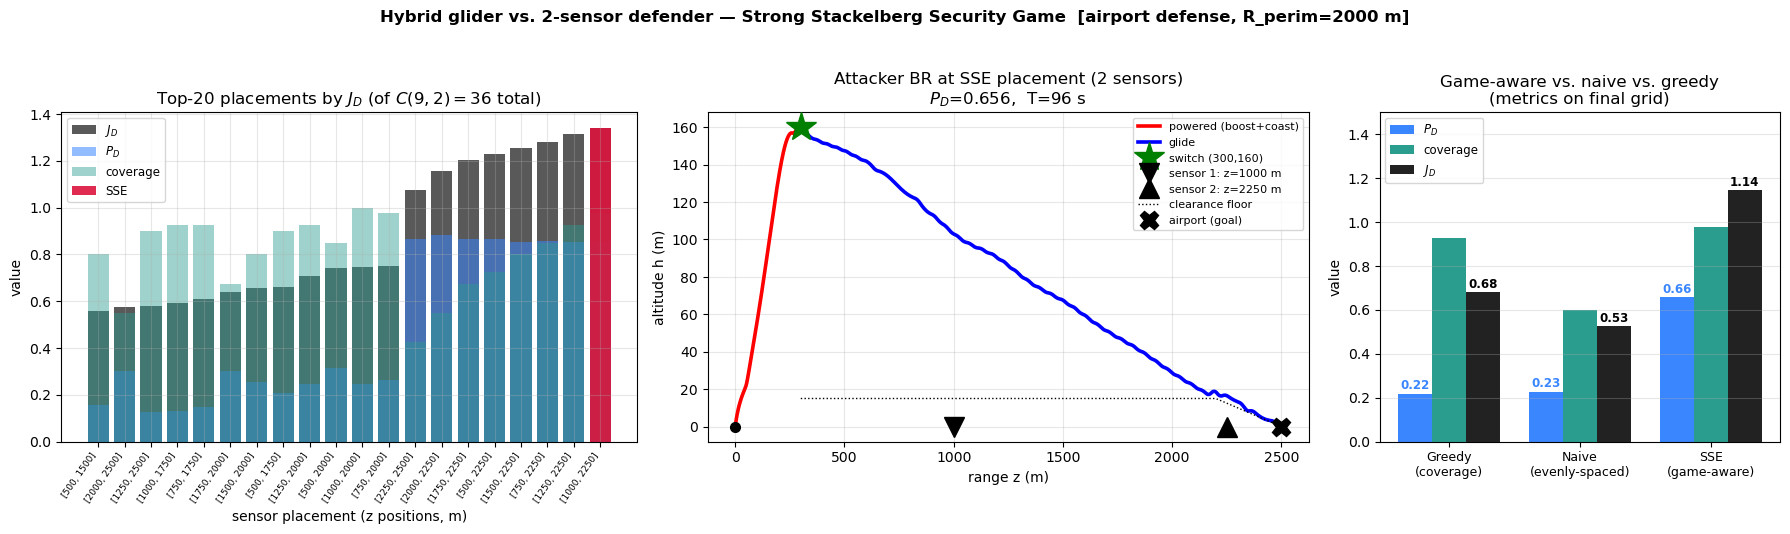

In [15]:
NA_C, AC_C, COV_C = '#E07B39', '#3A86FF', '#2a9d8f'
fig, ax = plt.subplots(1, 3, figsize=(18, 5.4),
                       gridspec_kw={'width_ratios': [2.3, 2.4, 1.6]})
fig.suptitle(f'Hybrid glider vs. {N_SENSORS}-sensor defender — Strong Stackelberg Security Game  '
             f'[airport defense, R_perim={R_PERIM:.0f} m]',
             fontsize=12, fontweight='bold')

# --- Panel A: leader payoff over placement set ---
if N_SENSORS == 1:
    zds = [r['sensors'][0][0] for r in sweep]
    ax[0].plot(zds, [r['J_D'] for r in sweep], 'o-', color='#222', lw=2.2, label=r'$J_D$')
    ax[0].plot(zds, [r['P_D'] for r in sweep], 's--', color=AC_C, lw=1.7, label=r'$P_D$')
    ax[0].plot(zds, [r['cov'] for r in sweep], '^:', color=COV_C, lw=1.7, label='coverage')
    ax[0].plot(sse['sensors'][0][0], sse['J_D'], '*', color='crimson', ms=24, zorder=6, label='SSE')
    if naive:  ax[0].axvline(naive['sensors'][0][0],  color='gray', ls=':', alpha=0.7)
    if greedy: ax[0].axvline(greedy['sensors'][0][0], color=COV_C,  ls=':', alpha=0.6)
    ax[0].set_xlabel(r'sensor site $z_d$ (m)')
    ax[0].set_title(f'Leader payoff over {len(sweep)} placements (N=1)')
else:
    # bar chart of top placements sorted by J_D
    sorted_sweep = sorted(sweep, key=lambda r: r['J_D'])
    n_show = min(len(sorted_sweep), 20)
    top = sorted_sweep[-n_show:]
    xs = np.arange(n_show)
    ax[0].bar(xs, [r['J_D'] for r in top], color='#222', alpha=0.75, label=r'$J_D$')
    ax[0].bar(xs, [r['P_D'] for r in top], color=AC_C,   alpha=0.55, label=r'$P_D$')
    ax[0].bar(xs, [r['cov'] for r in top], color=COV_C,  alpha=0.45, label='coverage')
    sse_key = _sensors_key(sse['sensors'])
    for i, r in enumerate(top):
        if _sensors_key(r['sensors']) == sse_key:
            ax[0].bar(i, r['J_D'], color='crimson', alpha=0.9, label='SSE')
    ax[0].set_xticks(xs)
    ax[0].set_xticklabels([r['sensor_label'] for r in top],
                          rotation=55, ha='right', fontsize=6.5)
    ax[0].set_xlabel('sensor placement (z positions, m)')
    ax[0].set_title(f'Top-{n_show} placements by $J_D$ '
                    f'(of $C({len(D_SITES)},{N_SENSORS})={len(sweep)}$ total)')
ax[0].set_ylabel('value'); ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.3)

# --- Panel B: SSE attacker best-response trajectory + all sensor sites ---
brf = sse_f['br']
pz = [p[0] for p in brf['pow_pts']];   ph = [p[1] for p in brf['pow_pts']]
gz = [p[0] for p in brf['glide_pts']]; gh = [p[1] for p in brf['glide_pts']]
ax[1].plot(pz, ph, 'r-', lw=2.6, label='powered (boost+coast)')
ax[1].plot(gz, gh, 'b-', lw=2.6, label='glide')
ax[1].plot(brf['z_sw'], brf['h_sw'], 'g*', ms=22, zorder=6,
           label=f'switch ({brf["z_sw"]:.0f},{brf["h_sw"]:.0f})')
sensor_markers = ['kv', 'k^', 'ks', 'kD', 'kP']
for i, s in enumerate(sse_f['sensors']):
    mk = sensor_markers[i % len(sensor_markers)]
    ax[1].plot(s[0], s[1], mk, ms=14, zorder=6,
               label=f'sensor {i+1}: z={s[0]:.0f} m')
zf_arr = np.linspace(brf['z_sw'], Z_GOAL, 250)
ax[1].plot(zf_arr, [minclear(z, H_CLEAR, Z_FLARE) for z in zf_arr], 'k:', lw=1, label='clearance floor')
ax[1].plot(0, 0, 'ko', ms=7); ax[1].plot(Z_GOAL, 0, 'kX', ms=13, label='airport (goal)')
ax[1].set_xlabel('range z (m)'); ax[1].set_ylabel('altitude h (m)')
ax[1].set_title(f'Attacker BR at SSE placement ({N_SENSORS} sensors)\n'
                f'$P_D$={sse_f["P_D"]:.3f},  T={sse_f["T"]:.0f} s')
ax[1].legend(fontsize=8, loc='upper right'); ax[1].grid(alpha=0.3)

# --- Panel C: game-aware vs naive vs greedy ---
strats = [(lbl, r) for lbl, r in
          [('Greedy\n(coverage)', greedy_f), ('Naive\n(evenly-spaced)', naive_f),
           ('SSE\n(game-aware)', sse_f)] if r]
x = np.arange(len(strats)); w = 0.26
ax[2].bar(x - w, [s[1]['P_D'] for s in strats], w, label=r'$P_D$',   color=AC_C)
ax[2].bar(x,     [s[1]['cov'] for s in strats], w, label='coverage', color=COV_C)
ax[2].bar(x + w, [s[1]['J_D'] for s in strats], w, label=r'$J_D$',   color='#222')
for i, s in enumerate(strats):
    ax[2].text(i - w, s[1]['P_D'] + 0.02, f"{s[1]['P_D']:.2f}",
               ha='center', fontsize=8.5, color=AC_C, fontweight='bold')
    ax[2].text(i + w, s[1]['J_D'] + 0.02, f"{s[1]['J_D']:.2f}",
               ha='center', fontsize=8.5, fontweight='bold')
ax[2].set_xticks(x); ax[2].set_xticklabels([s[0] for s in strats], fontsize=9)
ax[2].set_ylabel('value'); ax[2].set_ylim(0, 1.5)
ax[2].set_title('Game-aware vs. naive vs. greedy\n(metrics on final grid)')
ax[2].legend(fontsize=8.5, loc='upper left'); ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [16]:
# --- Summary table ---
print(f'{"Strategy":<22}{"sensors":>26}{"P_D":>8}{"coverage":>10}{"J_D":>8}{"T (s)":>8}')
print('-' * 82)
for name, r in [('Greedy (coverage)', greedy_f), ('Naive (evenly-spaced)', naive_f),
                ('SSE (game-aware)', sse_f)]:
    if r:
        print(f'{name:<22}{r["sensor_label"]:>26}{r["P_D"]:>8.3f}{r["cov"]:>10.2f}'
              f'{r["J_D"]:>8.3f}{r["T"]:>8.1f}')
print()
if sse_f and greedy_f:
    dP = sse_f['P_D'] - greedy_f['P_D']
    pct = 100*dP/greedy_f['P_D'] if greedy_f['P_D'] > 0 else float('inf')
    print(f'SSE vs greedy: P_D {greedy_f["P_D"]:.3f} -> {sse_f["P_D"]:.3f}  '
          f'(+{dP:.3f}, {pct:.0f}% higher detection of the best-responding attacker)')

Strategy                                 sensors     P_D  coverage     J_D   T (s)
----------------------------------------------------------------------------------
Greedy (coverage)                   [1250, 2000]   0.219      0.93   0.681    96.2
Naive (evenly-spaced)                [500, 2500]   0.227      0.60   0.527   115.8
SSE (game-aware)                    [1000, 2250]   0.656      0.97   1.144    96.2

SSE vs greedy: P_D 0.219 -> 0.656  (+0.438, 200% higher detection of the best-responding attacker)


## Notes and next steps

**Multi-sensor Poisson fusion.** Adding sensors strictly increases $H$ and hence
$P_D$ against any fixed trajectory. The interesting question is *where* to place
them: sensors near each other provide redundant coverage; spread sensors force the
attacker to route through multiple threat zones. The SSE captures this trade-off;
the coverage-greedy baseline does not.

**Scalability.** The enumeration cost grows as $\binom{|D|}{N}\times$(DP cost).
With $|D|=9$ and $N=2$ this is 36 placements; $N=3$ is 84. For larger $N$ or
denser candidate sets, replace enumeration with a greedy SSE approximation
(exploit submodularity of $P_D$ in the sensor positions) or branch-and-bound.

**Powered phase is still detection-blind.** The boost DP minimizes energy only;
acoustic/radar hazard during the powered phase is scored post-hoc per switch.
A full follower would route the boost away from acoustic sensors.

**Backward compatibility.** Set `N_SENSORS = 1` to recover the single-sensor
results from `hybrid_glider_SSG.ipynb` exactly.